In [6]:
rois = [[(420, 313), (444, 319), (427, 511), (400, 510)],
        [(561, 323), (615, 309), (634, 507), (572, 507)],
        [(700, 298), (753, 297), (750, 507), (700, 507)],
        [(930, 351), (990, 356), (959, 510), (898, 520)],
        [(1183, 178), (1242, 183), (1232, 505), (1167, 510)],
        [(1355, 180), (1400, 190), (1374, 507), (1299, 502)]]



# set video path
video_path = 'NightCTRL1.mov'

## Diplays first frame with ROIs

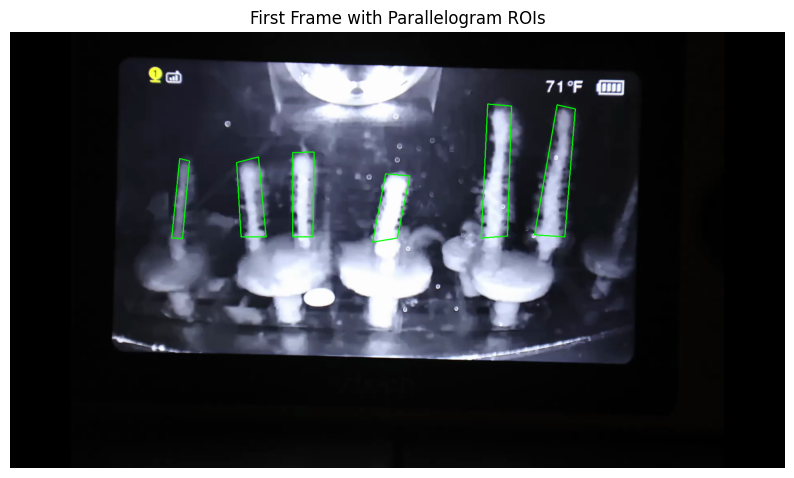

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def display_first_frame_with_parallelograms(video_path, rois):
    """
    Displays the first frame of a video with multiple parallelogram-shaped ROIs.

    Parameters:
    video_path (str): Path to the video file.
    rois (list of lists): List of parallelograms, each defined by 4 vertices [(x1, y1), (x2, y2), (x3, y3), (x4, y4)].
    """
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    
    # Check if the video file was opened successfully
    if not cap.isOpened():
        print("Error: Could not open video file.")
        return
    
    # Read the first frame
    ret, frame = cap.read()
    
    if ret:
        # Draw each parallelogram ROI on the frame
        for roi in rois:
            # Convert the list of points to a numpy array of shape (4, 1, 2) for cv2.polylines
            pts = np.array(roi, np.int32).reshape((-1, 1, 2))
            # Draw the parallelogram
            cv2.polylines(frame, [pts], isClosed=True, color=(0, 255, 0), thickness=2)  # Green line
        
        # Convert the frame from BGR (OpenCV default) to RGB (for matplotlib)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Display the frame with the parallelograms using matplotlib
        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.axis('off')  # Hide axes
        plt.title("First Frame with Parallelogram ROIs")
        plt.show()
    else:
        print("Error: Could not read the first frame.")
    
    # Release the video capture object
    cap.release()

# Example usage
#video_path = 'ControlTank3Week2.mov'  # Replace with the path to your video file
display_first_frame_with_parallelograms(video_path, rois)


## Collects data

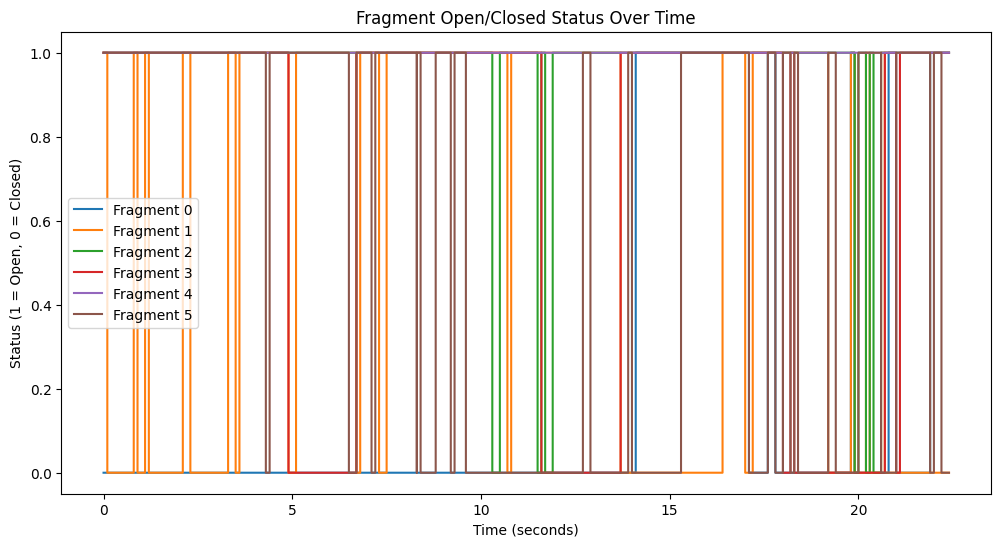


Fragment 0:
  Total time open: 3.9 seconds
  Total time closed: 18.6 seconds
  Open during day: 0 seconds
  Open during night: 3.4 seconds
  Closed during day: 0 seconds
  Closed during night: 18.6 seconds

Fragment 1:
  Total time open: 13.2 seconds
  Total time closed: 9.2 seconds
  Open during day: 0 seconds
  Open during night: 13.2 seconds
  Closed during day: 0 seconds
  Closed during night: 8.7 seconds

Fragment 2:
  Total time open: 21.5 seconds
  Total time closed: 0.9 seconds
  Open during day: 0 seconds
  Open during night: 21.0 seconds
  Closed during day: 0 seconds
  Closed during night: 0.9 seconds

Fragment 3:
  Total time open: 15.9 seconds
  Total time closed: 6.5 seconds
  Open during day: 0 seconds
  Open during night: 15.4 seconds
  Closed during day: 0 seconds
  Closed during night: 6.5 seconds

Fragment 4:
  Total time open: 22.4 seconds
  Total time closed: 0 seconds
  Open during day: 0 seconds
  Open during night: 22.0 seconds
  Closed during day: 0 seconds
  

In [8]:
import cv2
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# === Define Day/Night Periods in seconds ===
# Example: First hour is day, second hour is night
day_night_periods = [
    (0, 22, 'night')
    # Add more as needed
]

# === Helper to determine period label ===
def get_time_period_label(time_sec, periods):
    for start, end, label in periods:
        if start <= time_sec < end:
            return label
    return 'unknown'  # Fallback if not defined

# === Initialize Data Structures ===
duration_data = defaultdict(lambda: {
    "open": 0, "closed": 0,
    "open_day": 0, "open_night": 0,
    "closed_day": 0, "closed_night": 0
})
status_over_time = defaultdict(list)  # Store open/closed status over time

# === Open Video File ===
video_path = 'NightCTRL1.mov'  # Update path if needed
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)

# === Function to Process a Parallelogram ROI ===
def process_contours(frame, parallelogram):
    mask = np.zeros(frame.shape[:2], dtype=np.uint8)
    pts = np.array(parallelogram, dtype=np.int32)
    cv2.fillPoly(mask, [pts], 255)
    fragment_roi = cv2.bitwise_and(frame, frame, mask=mask)
    gray_roi = cv2.cvtColor(fragment_roi, cv2.COLOR_BGR2GRAY)
    blurred_roi = cv2.GaussianBlur(gray_roi, (19, 19), 0)
    _, thresholded_mask = cv2.threshold(blurred_roi,75, 255, cv2.THRESH_BINARY)

    boundary_mask = np.zeros_like(thresholded_mask, dtype=np.uint8)
    p0, p1, p2, p3 = parallelogram
    cv2.line(boundary_mask, p0, p1, 255, thickness=1)
    cv2.line(boundary_mask, p0, p3, 255, thickness=1)
    cv2.line(boundary_mask, p1, p2, 255, thickness=1)
    # No bottom edge

    return thresholded_mask, boundary_mask, pts

# === Frame Processing Loop ===
frame_index = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred_frame = cv2.GaussianBlur(gray_frame, (19, 19), 0)
    time_sec = round(frame_index / fps, 1)
    period_label = get_time_period_label(time_sec, day_night_periods)

    for i, roi in enumerate(rois):
        thresholded_mask, boundary_mask, pts = process_contours(frame, roi)
        overlap_mask = cv2.bitwise_and(thresholded_mask, boundary_mask)
        fragment_open = np.any((overlap_mask >= 75) & (overlap_mask <= 255))
        fragment_status = 1 if fragment_open else 0
        increment = 1 / fps

        # === Update Duration Counters ===
        if fragment_open:
            duration_data[i]["open"] += increment
            if period_label == 'day':
                duration_data[i]["open_day"] += increment
            elif period_label == 'night':
                duration_data[i]["open_night"] += increment
        else:
            duration_data[i]["closed"] += increment
            if period_label == 'day':
                duration_data[i]["closed_day"] += increment
            elif period_label == 'night':
                duration_data[i]["closed_night"] += increment

        status_over_time[i].append((time_sec, fragment_status))

        # === Visualization Overlay ===
        color = 255 if fragment_open else 0
        cv2.polylines(blurred_frame, [np.array(roi, dtype=np.int32)], isClosed=True, color=color, thickness=2)

    # === Frame Display ===
    _, thresholded_frame = cv2.threshold(blurred_frame, 75, 255, cv2.THRESH_BINARY)
    combined_display = np.hstack([thresholded_frame, blurred_frame])
    cv2.imshow('Thresholded and Contoured Frame', combined_display)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_index += 1

# === Cleanup ===
cap.release()
cv2.destroyAllWindows()

# === Plotting Open/Closed Status Over Time ===
plt.figure(figsize=(12, 6))
for fragment_id, time_series in status_over_time.items():
    times, statuses = zip(*time_series)
    plt.step(times, statuses, label=f"Fragment {fragment_id}", where='post')

plt.xlabel("Time (seconds)")
plt.ylabel("Status (1 = Open, 0 = Closed)")
plt.title("Fragment Open/Closed Status Over Time")
plt.legend()
plt.show()

# === Print Summary ===
for fragment_id, durations in duration_data.items():
    print(f"\nFragment {fragment_id}:")
    print(f"  Total time open: {round(durations['open'], 1)} seconds")
    print(f"  Total time closed: {round(durations['closed'], 1)} seconds")
    print(f"  Open during day: {round(durations['open_day'], 1)} seconds")
    print(f"  Open during night: {round(durations['open_night'], 1)} seconds")
    print(f"  Closed during day: {round(durations['closed_day'], 1)} seconds")
    print(f"  Closed during night: {round(durations['closed_night'], 1)} seconds")


## Plays whole video with ROIs outlined

In [6]:

import cv2
import numpy as np


# Open the video
video_path = 'ControlTank1Week2.mov'  # Update this path if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
    exit()

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video loaded: {video_path}")
print(f"Resolution: {width}x{height}, FPS: {fps}")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Draw parallelogram ROIs on the frame
    for roi in rois:
        pts = np.array(roi, np.int32).reshape((-1, 1, 2))
        cv2.polylines(frame, [pts], isClosed=True, color=(0, 255, 0), thickness=2)  # Green parallelogram

    # Display the frame with the ROIs
    cv2.imshow('Video with ROIs', frame)

    # Break the loop if 'q' is pressed
    if cv2.waitKey(int(1000 / fps)) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


Video loaded: ControlTank1Week1.mov
Resolution: 1920x1080, FPS: 29.97002997002997


2025-01-28 12:09:16.864 Python[64080:623745] +[IMKClient subclass]: chose IMKClient_Modern
2025-01-28 12:09:16.865 Python[64080:623745] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [ ]:
import cv2
import numpy as np

# Open the video
video_path = 'ControlTank1Week2.mov'  # Update this path if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
    exit()

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video loaded: {video_path}")
print(f"Resolution: {width}x{height}, FPS: {fps}")

# Define the output video writer
output_path = video_path.rsplit('.', 1)[0] + '_with_rois.mov'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for .mov files
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Draw parallelogram ROIs on the frame
    for roi in rois:
        pts = np.array(roi, np.int32).reshape((-1, 1, 2))
        cv2.polylines(frame, [pts], isClosed=True, color=(0, 255, 0), thickness=2)  # Green parallelogram

    # Write the frame to the output video
    out.write(frame)

    # Display the frame with the ROIs
    cv2.imshow('Video with ROIs', frame)

    # Break the loop if 'q' is pressed
    if cv2.waitKey(int(1000 / fps)) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Output video saved as {output_path}")


Video loaded: ControlTank1Week1.mov
Resolution: 1920x1080, FPS: 29.97002997002997
